In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("/content/train (1).csv")
test = pd.read_csv("/content/test.csv")

print("Train shape:", train.shape)
print("Test Shape:", test.shape)

Train shape: (891, 12)
Test Shape: (418, 11)


In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
missing_value = train.isnull().sum()
missing_percent = (missing_value / len(train)) * 100
missing_df = pd.DataFrame({
    "Missing value" : missing_value,
    "Percentage" : missing_percent
})
missing_df[missing_df["Missing value"] > 0].sort_values(
    by = "Percentage",
    ascending = False
)

,Missing value,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


In [ ]:
train.duplicated().sum()

np.int64(0)

In [ ]:
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
# survival rate
(train['Survived'].value_counts(normalize=True)*100).round(2)

,proportion
Survived,
0,61.62
1,38.38


In [ ]:
pd.crosstab(
    train['Sex'],
    train['Survived'],
    normalize="index"
)*100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [ ]:
train['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: >

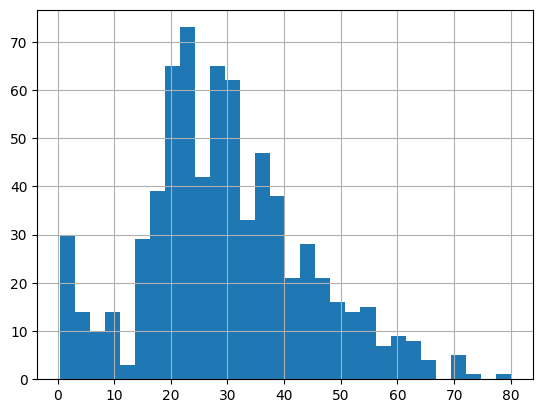

In [ ]:
train['Age'].hist(bins=30)

In [ ]:
train.groupby("Survived")['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [ ]:
pd.crosstab(
    train["Pclass"],
    train["Survived"],
    normalize="index"
)*100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [ ]:
# Fare Analysis
train['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: >

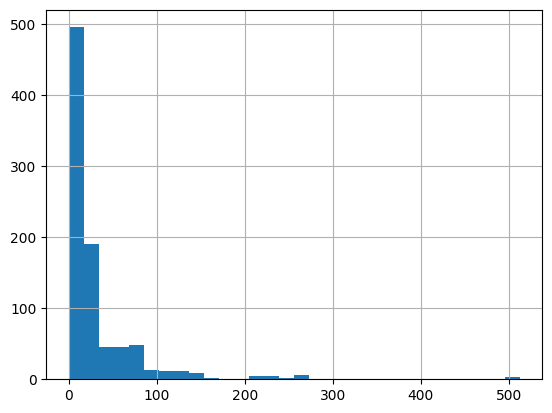

In [ ]:
train['Fare'].hist(bins=30)

In [ ]:
train.groupby("Survived")['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


In [ ]:
train['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
pd.crosstab(
    train['Embarked'],
    train['Survived'],
    normalize="index"
) * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


In [ ]:
train['SibSp'].value_counts().sort_index()

,count
SibSp,
0,608
1,209
2,28
3,16
4,18
5,5
8,7


In [ ]:
pd.crosstab(
    train['SibSp'],
    train['Survived'],
    normalize = "index"
) * 100

Survived,0,1
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


In [ ]:
# parch = parent + children
train['Parch'].value_counts().sort_index()

,count
Parch,
0,678
1,118
2,80
3,5
4,4
5,5
6,1


In [ ]:
pd.crosstab(
    train['Parch'],
    train['Survived'],
    normalize='index'
)*100

Survived,0,1
Parch,,
0,65.634218,34.365782
1,44.915254,55.084746
2,50.000000,50.000000
3,40.000000,60.000000
4,100.000000,0.000000
5,80.000000,20.000000
6,100.000000,0.000000


In [ ]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

In [ ]:
train['FamilySize']

,FamilySize
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


In [ ]:
pd.crosstab(
    train['FamilySize'],
    train['Survived'],
    normalize='index'
)*100

Survived,0,1
FamilySize,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


In [ ]:
train_df = train.copy()
test_df = test.copy()

In [ ]:
# store statistics from training data
age_median = train_df["Age"].median()
fare_median = train_df["Fare"].median()
embarked_mode = train_df["Embarked"].mode()[0]

#Fill missing values
train_df['Age'] = train_df['Age'].fillna(age_median)
test_df["Age"] = test_df["Age"].fillna(age_median)

train_df['Fare'] = train_df["Fare"].fillna(fare_median)
test_df["Fare"] = test_df["Fare"].fillna(fare_median)

train_df["Embarked"] = train_df["Embarked"].fillna(embarked_mode)
test_df["Embarked"] = test_df["Embarked"].fillna(embarked_mode)

In [ ]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,327


In [ ]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

In [ ]:
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1

In [ ]:
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)
test_df["IsAlone"] = (test_df["FamilySize"] == 1).astype(int)

In [ ]:
# Extract title from passenger name
train_df["Title"] = train_df["Name"].str.extract(r",\s*([^\.]+)\.")
test_df["Title"] = test_df["Name"].str.extract(r",\s*([^\.]+)\.")

In [ ]:
train_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
#Group rare titles
rare_titles = [
    "Lady","the Countess", "Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"
]
train_df["Title"] = train_df["Title"].replace(rare_titles,"Rare")
test_df["Title"] = test_df["Title"].replace(rare_titles,"Rare")

# Normalize similar titles
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}

train_df['Title'] = train_df["Title"].replace(title_mapping)
test_df["Title"] = test_df["Title"].replace(title_mapping)

In [ ]:
train_df["Title"].value_counts()

,count
Title,
Mr,517
Miss,185
Mrs,126
Master,40
Rare,23


In [ ]:
#create HasCabin feature
train_df["HasCabin"] = train_df["Cabin"].notna().astype(int)
test_df["HasCabin"] = test_df["Cabin"].notna().astype(int)

In [ ]:
drop_cols = ["PassengerId","Name","Ticket","Cabin"]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [ ]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr,0
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs,1
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss,0
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs,1
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr,0


In [ ]:
categorical_cols = ["Sex", "Embarked", "Title"]

# Process train_df
cols_to_encode_train = [col for col in categorical_cols if col in train_df.columns]
if cols_to_encode_train:
    train_df = pd.get_dummies(
        train_df,
        columns=cols_to_encode_train,
        drop_first=True,
        dtype=int
    )

# Process test_df
cols_to_encode_test = [col for col in categorical_cols if col in test_df.columns]
if cols_to_encode_test:
    test_df = pd.get_dummies(
        test_df,
        columns=cols_to_encode_test,
        drop_first=True,
        dtype=int
    )

# Separate target variable
y = train_df["Survived"]

# Training features
X = train_df.drop(columns=["Survived"])

# Test features
X_test = test_df.copy()

# Ensure train and test have identical feature columns
X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Verify shapes
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (891, 15)
y shape: (891,)
X_test shape: (418, 15)


In [ ]:
from sklearn.model_selection import train_test_split

# split data into training and validation sets
X_train,X_valid,y_train,y_valid = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify = y
)

print("Training Features:",X_train.shape)
print("Training Labels:",y_train.shape)
print("Validation Features:",X_valid.shape)
print("Validation Labels:",y_valid.shape)

Training Features: (712, 15)
Training Labels: (712,)
Validation Features: (179, 15)
Validation Labels: (179,)


In [ ]:
from sklearn.linear_model import LogisticRegression
# Initialize the model
log_reg = LogisticRegression(max_iter=1000,random_state=42)

log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score
#predictions on validation set
y_pred = log_reg.predict(X_valid)

#Accuracy
accuracy = accuracy_score(y_valid,y_pred)
print(f"Logistic Regression Accuracy: {accuracy:4f}")

Logistic Regression Accuracy: 0.810056


In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
rf_pred = rf.predict(X_valid)

# Accuracy
rf_accuracy = accuracy_score(y_valid, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8101


In [ ]:
from sklearn.model_selection import cross_val_score

# Logistic Regression Cross Validation
lr_cv = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# Random Forest Cross Validation
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", lr_cv.mean())
print("Random Forest CV Accuracy:", rf_cv.mean())

Logistic Regression CV Accuracy: 0.821542903772519
Random Forest CV Accuracy: 0.8080785889146946


In [ ]:
# Train final Logistic Regression model on full training data
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(X, y)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
test_predictions = final_model.predict(X_test)
test_predictions

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv("Submission.csv",index=False)
print("Submission.csv created successfully!")

Submission.csv created successfully!


In [ ]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
from google.colab import files
files.download("Submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'test.csv', 'train (1).csv', 'Submission.csv', 'sample_data']


In [ ]:
import joblib

In [ ]:
#save the trained model
joblib.dump(final_model,"logistic_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# save features names
joblib.dump(X.columns.tolist(),"feature_columns.pkl")
print("Features columns saved successfully!")

Features columns saved successfully!
